Curso: Seminario de Sistemas 2

Estudiante: Josue Daniel Solis Osorio

Carné: 202001574

# 1. Carga de datos

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("1. Cargando datos...")
df_orig = pd.read_csv('dataset_sucio.csv')
df = df_orig.copy()
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

1. Cargando datos...
Dataset cargado: 5000 filas, 7 columnas


# 2. Eliminación de duplicados


In [16]:
print("2. Eliminando duplicados...")
df.drop_duplicates(inplace=True)
print(f"Dataset después de eliminar duplicados: {df.shape[0]} filas")

2. Eliminando duplicados...
Dataset después de eliminar duplicados: 4900 filas


# 3. Tratamiento de valores faltantes y estandarización de strings

In [17]:
print("3. Tratando valores faltantes y estandarizando strings...")
# Columnas de texto: Limpieza de espacios y formato Título
string_cols = ['nombre', 'genero', 'ciudad', 'categoria']
for col in string_cols:
    # Primero llenar NaN con 'Desconocido'
    df[col] = df[col].fillna('Desconocido')
    # Convertir a string, limpiar espacios y aplicar título
    df[col] = df[col].astype(str).str.strip().str.title()
    # Reemplazar valores vacíos por 'Desconocido'
    df.loc[df[col].isin(['Nan', 'None', '', ' ']), col] = 'Desconocido'
print("String columns estandarizadas")

3. Tratando valores faltantes y estandarizando strings...
String columns estandarizadas


# 4. Estandarización de Género


In [18]:
print("4. Estandarizando género...")
# Mapeo a categorías claras (Masculino, Femenino, Desconocido)
df['genero'] = df['genero'].apply(lambda x: 'Masculino' if str(x).upper().startswith('M') else 
                                 ('Femenino' if str(x).upper().startswith('F') else 'Desconocido'))
print(f"Géneros únicos: {df['genero'].unique()}")

4. Estandarizando género...
Géneros únicos: <StringArray>
['Masculino', 'Femenino', 'Desconocido']
Length: 3, dtype: str


# 5. Limpieza de Gasto (Numérico)


In [19]:
print("5. Limpiando gasto (valores numéricos)...")
# Corregir separador decimal (coma por punto) y convertir a float
df['gasto_q'] = df['gasto_q'].astype(str).str.replace(',', '.', regex=False)
df['gasto_q'] = pd.to_numeric(df['gasto_q'], errors='coerce')
# Imputación de valores faltantes con la mediana
df['gasto_q'] = df['gasto_q'].fillna(df['gasto_q'].median())
print(f"Gasto procesado - Min: {df['gasto_q'].min()}, Max: {df['gasto_q'].max()}")

5. Limpiando gasto (valores numéricos)...
Gasto procesado - Min: 0.18, Max: 499.86


# 6. Estandarización de Fechas

In [20]:
print("6. Estandarizando fechas...")
# Manejo de formatos mixtos (YYYY-MM-DD y DD/MM/YYYY)
df['fecha_registro'] = pd.to_datetime(df['fecha_registro'], dayfirst=True, errors='coerce')
print(f"Fechas procesadas - Rango: {df['fecha_registro'].min()} a {df['fecha_registro'].max()}")

6. Estandarizando fechas...
Fechas procesadas - Rango: 2026-01-01 00:00:00 a 2026-03-01 00:00:00


C:\Users\andhy\AppData\Local\Temp\ipykernel_21280\2832277611.py:3: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['fecha_registro'] = pd.to_datetime(df['fecha_registro'], dayfirst=True, errors='coerce')


# 7. Exportación del dataset limpio


In [21]:
print("7. Exportando dataset limpio y realizando análisis...")
df.to_csv('dataset_limpio.csv', index=False)
print("Dataset limpio exportado a 'dataset_limpio.csv'")

# --- Análisis con Tablas Pivote ---
# Comparación de registros únicos por columna
resumen_limpieza = pd.DataFrame({
    'Columna': ['genero', 'ciudad', 'categoria'],
    'Original (Únicos)': [df_orig['genero'].nunique(), df_orig['ciudad'].nunique(), df_orig['categoria'].nunique()],
    'Limpio (Únicos)': [df['genero'].nunique(), df['ciudad'].nunique(), df['categoria'].nunique()]
})

print("\nResumen de Estandarización:")
print(resumen_limpieza)

# Pivot: Gasto total por ciudad y categoría
pivot_final = df.pivot_table(index='ciudad', columns='categoria', values='gasto_q', aggfunc='sum', fill_value=0)
print("\nPivot Table (Gasto Total):")
print(pivot_final.head())

7. Exportando dataset limpio y realizando análisis...
Dataset limpio exportado a 'dataset_limpio.csv'

Resumen de Estandarización:
     Columna  Original (Únicos)  Limpio (Únicos)
0     genero                  7                3
1     ciudad                 41                9
2  categoria                 16                4

Pivot Table (Gasto Total):
categoria      Education      Food    Retail  Services
ciudad                                                
Amatitlan       35704.38  35748.53  37780.95  39409.67
Antigua         38826.13  37766.59  31697.80  33475.18
Chimaltenango   37304.46  37428.76  39108.18  34360.03
Desconocido     10485.15  14946.07  14479.64  14245.48
Escuintla       38491.46  36467.01  38926.20  36373.54


# 8. Graficas con pandas

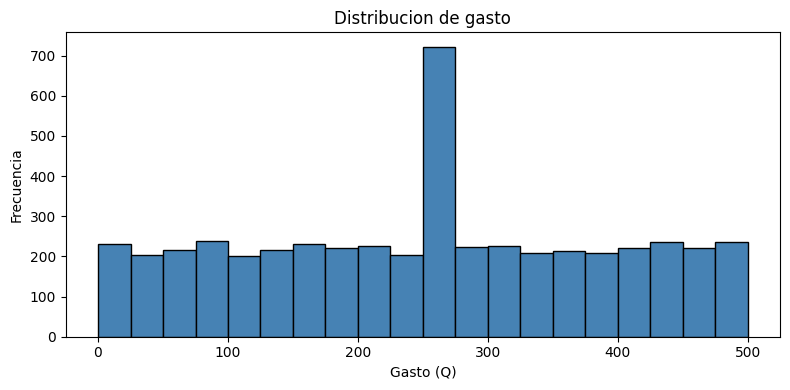

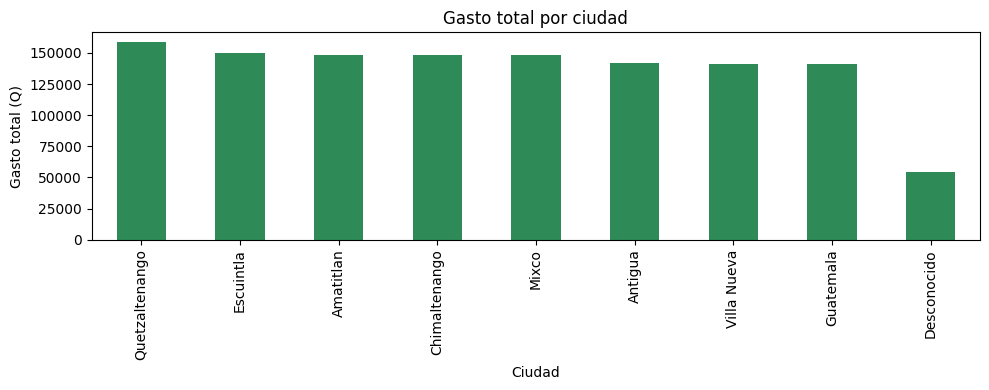

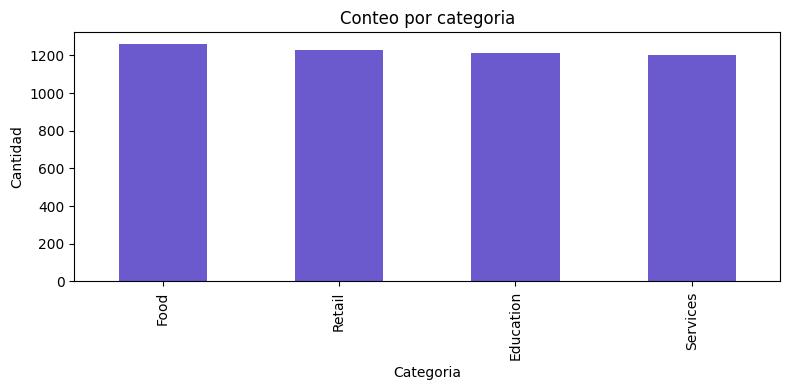

In [22]:
# Histograma de gasto
plt.figure(figsize=(8, 4))
df['gasto_q'].plot(kind='hist', bins=20, color='steelblue', edgecolor='black')
plt.title('Distribucion de gasto')
plt.xlabel('Gasto (Q)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Gasto total por ciudad
plt.figure(figsize=(10, 4))
df.groupby('ciudad')['gasto_q'].sum().sort_values(ascending=False).plot(kind='bar', color='seagreen')
plt.title('Gasto total por ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Gasto total (Q)')
plt.tight_layout()
plt.show()

# Conteo por categoria
plt.figure(figsize=(8, 4))
df['categoria'].value_counts().plot(kind='bar', color='slateblue')
plt.title('Conteo por categoria')
plt.xlabel('Categoria')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()